In [1]:
!pip install pennylane pennylane-lightning torch torchvision scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 37.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 60.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 6.7 MB/s eta 0:00:00


In [2]:
from google.colab import files

uploaded = files.upload()

Saving X_test_pca.npy to X_test_pca.npy
Saving y_test.npy to y_test.npy
Saving y_train.npy to y_train.npy
Saving X_train_pca.npy to X_train_pca.npy


In [3]:
import numpy as np

X_train = np.load("X_train_pca.npy")
X_test = np.load("X_test_pca.npy")

y_train = np.load("y_train.npy")
y_test = np.load("y_test.npy")

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(2000, 4)
(500, 4)
(2000,)
(500,)


Convert to PyTorch

In [4]:
import torch

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

print(X_train.shape)

torch.Size([2000, 4])


Import Quantum Libraries

In [5]:
import pennylane as qml
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score

import matplotlib.pyplot as plt

Define Quantum Device

We will use:

4 qubits
2 variational layers

In [6]:
n_qubits = 4
n_layers = 2

dev = qml.device(
    "lightning.qubit",
    wires=n_qubits
)

In [7]:
print(dev)

<lightning.qubit device (wires=4) at 0x7fdc813cda90>


Create the Quantum Circuit

This is your Static VQC Baseline.

In [8]:
@qml.qnode(dev, interface="torch")

def quantum_circuit(inputs, weights):

    # Angle Encoding
    for i in range(n_qubits):
        qml.RY(inputs[i], wires=i)

    # Variational Layers
    for layer in range(n_layers):

        for q in range(n_qubits):
            qml.RY(weights[layer, q], wires=q)

        for q in range(n_qubits - 1):
            qml.CNOT(wires=[q, q+1])

    return qml.expval(qml.PauliZ(0))

Quick Circuit Test

Create random weights.

In [9]:
weights = torch.randn(
    n_layers,
    n_qubits
)

sample = X_train[0]

output = quantum_circuit(
    sample,
    weights
)

print(output)

tensor(0.3524)


Visualize the Circuit

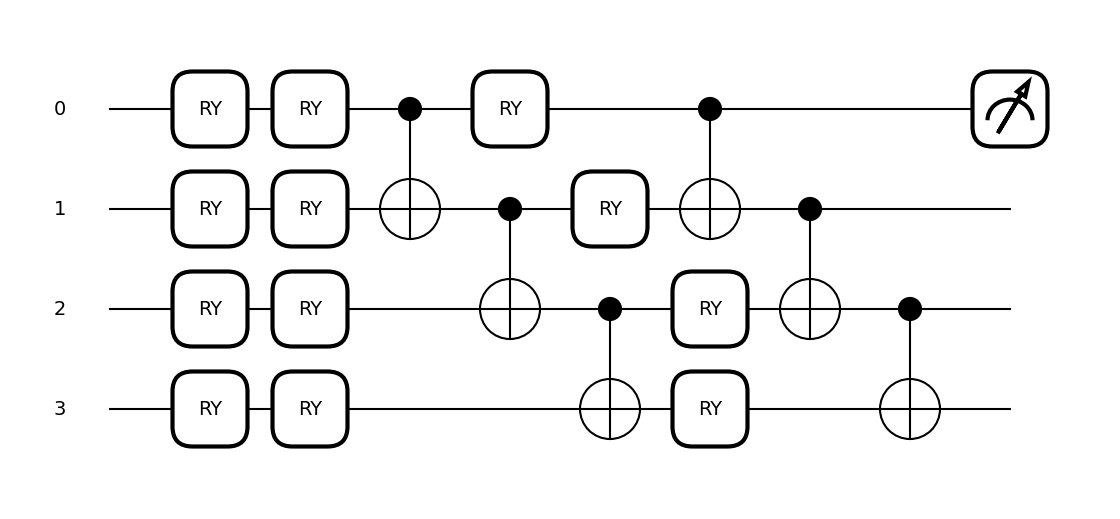

In [10]:
qml.draw_mpl(quantum_circuit)(
    X_train[0],
    weights
)

plt.show()

Build the Hybrid Quantum Classifier

In [11]:
class StaticVQC(nn.Module):

    def __init__(self):

        super().__init__()

        self.weights = nn.Parameter(
            0.01 * torch.randn(
                n_layers,
                n_qubits
            )
        )

    def forward(self, x):

        outputs = []

        for sample in x:

            q_out = quantum_circuit(
                sample,
                self.weights
            )

            outputs.append(q_out)

        outputs = torch.stack(outputs)

        return torch.sigmoid(outputs)

In [12]:
#Instantiate model
model = StaticVQC()

print(model)

StaticVQC()


forward-pass test

In [13]:
sample_batch = X_train[:5]

predictions = model(sample_batch)

print(predictions)

tensor([0.4244, 0.3090, 0.2718, 0.2703, 0.2760], grad_fn=<SigmoidBackward0>)


In [14]:
criterion = nn.BCELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.01
)

In [15]:
optimizer.zero_grad()

preds = model(X_train[:32])

loss = criterion(
    preds,
    y_train[:32]
)

loss.backward()

optimizer.step()

print("Loss:", loss.item())

Loss: 0.9121895432472229


Are gradients non-zero?

In [16]:
for name, param in model.named_parameters():
    print(f"\n{name}")
    print(param.grad)


weights
tensor([[-2.0303e-01,  1.4404e-04,  3.0219e-18, -2.5213e-18],
        [-9.8642e-02, -6.1619e-19, -2.1692e-18,  0.0000e+00]])


In [17]:
epochs = 30

loss_history = []
gradient_variance_history = []

for epoch in range(epochs):

    optimizer.zero_grad()

    preds = model(X_train)

    loss = criterion(preds, y_train)

    loss.backward()

    grad_values = []

    for p in model.parameters():
        grad_values.extend(
            p.grad.detach().cpu().numpy().flatten()
        )

    grad_var = np.var(grad_values)

    gradient_variance_history.append(
        grad_var
    )

    optimizer.step()

    loss_history.append(
        loss.item()
    )

    print(
        f"Epoch {epoch+1:02d} | "
        f"Loss={loss.item():.4f} | "
        f"GradVar={grad_var:.8f}"
    )

Epoch 01 | Loss=0.9590 | GradVar=0.00392490
Epoch 02 | Loss=0.9569 | GradVar=0.00401736
Epoch 03 | Loss=0.9549 | GradVar=0.00411085
Epoch 04 | Loss=0.9527 | GradVar=0.00420508
Epoch 05 | Loss=0.9506 | GradVar=0.00429992
Epoch 06 | Loss=0.9484 | GradVar=0.00439534
Epoch 07 | Loss=0.9461 | GradVar=0.00449125
Epoch 08 | Loss=0.9438 | GradVar=0.00458767
Epoch 09 | Loss=0.9415 | GradVar=0.00468451
Epoch 10 | Loss=0.9391 | GradVar=0.00478172
Epoch 11 | Loss=0.9366 | GradVar=0.00487930
Epoch 12 | Loss=0.9341 | GradVar=0.00497714
Epoch 13 | Loss=0.9316 | GradVar=0.00507514
Epoch 14 | Loss=0.9289 | GradVar=0.00517324
Epoch 15 | Loss=0.9263 | GradVar=0.00527127
Epoch 16 | Loss=0.9235 | GradVar=0.00536916
Epoch 17 | Loss=0.9207 | GradVar=0.00546668
Epoch 18 | Loss=0.9178 | GradVar=0.00556375
Epoch 19 | Loss=0.9149 | GradVar=0.00566013
Epoch 20 | Loss=0.9119 | GradVar=0.00575564
Epoch 21 | Loss=0.9088 | GradVar=0.00585009
Epoch 22 | Loss=0.9057 | GradVar=0.00594322
Epoch 23 | Loss=0.9025 | GradVar

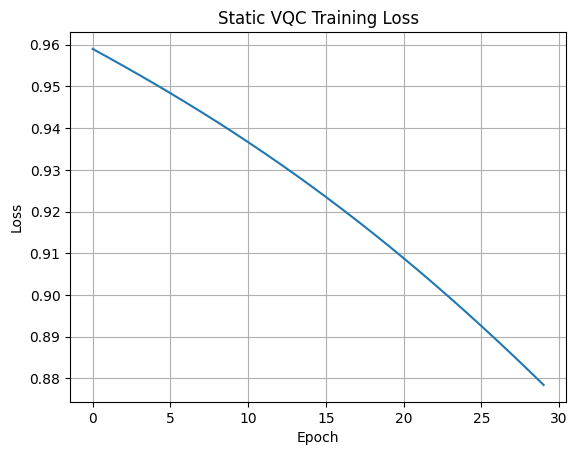

In [18]:
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Static VQC Training Loss")
plt.grid(True)
plt.show()

In [20]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score

with torch.no_grad():

    probs = model(X_test)

preds = (probs > 0.5).int()

acc = accuracy_score(
    y_test.numpy(),
    preds.numpy()
)

f1 = f1_score(
    y_test.numpy(),
    preds.numpy()
)

print("Accuracy =", acc)
print("F1 Score =", f1)

Accuracy = 0.328
F1 Score = 0.0918918918918919


Configuration:
Dataset: MNIST (0 vs 1)
Training Samples: 2000
Testing Samples: 500

PCA Components: 4
Variance Retained: 56.06%

Quantum Circuit:
- 4 qubits
- 2 variational layers
- Angle encoding
- Single Pauli-Z measurement

Training:
- Adam optimizer
- Learning rate = 0.01
- 30 epochs

Results:
Accuracy = 32.8%
F1 Score = 0.0919

Loss:
0.9590 → 0.8785

Gradient Variance:
0.0039 → 0.0066

Conclusion:
The static VQC exhibited stable optimization and
non-vanishing gradients but failed to achieve
satisfactory classification performance, indicating
insufficient representational capacity of the
single-measurement architecture.
